Loss:
adjustable ordinal loss

In [4]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models exists:", (PROJECT_ROOT / "models").exists())
print("utils exists:", (PROJECT_ROOT / "utils").exists())



Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
models exists: True
utils exists: True


In [5]:
import importlib
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils.train_utils
import models.loss_funcs

importlib.reload(utils.train_utils)
importlib.reload(models.loss_funcs)

from utils.dataset import get_dataloaders, print_dataset_info
from models.densenet import get_densenet121, count_trainable_parameters
from models.loss_funcs import HybridChenOrdinalLoss
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics, get_confusion_matrix


In [6]:
EXPERIMENT_NAME = "densenet121_hybrid_chen_ordinal_loss"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

ORDINAL_ALPHA = 0.1
PENALTY_DISTANCE = 2
SQUARE_LOSS = False
NORMALIZE_MATRIX = True

print("Experiment:", EXPERIMENT_NAME)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Max epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Monitor metric:", MONITOR_METRIC)
print("Ordinal alpha:", ORDINAL_ALPHA)
print("Penalty distance:", PENALTY_DISTANCE)
print("Square loss:", SQUARE_LOSS)
print("Normalize matrix:", NORMALIZE_MATRIX)




Experiment: densenet121_hybrid_chen_ordinal_loss
Image size: 224
Batch size: 32
Learning rate: 0.0001
Max epochs: 30
Patience: 7
Monitor metric: qwk
Ordinal alpha: 0.1
Penalty distance: 2
Square loss: False
Normalize matrix: True


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [8]:
SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [9]:
model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Trainable parameters: 6,958,981
Total parameters:     6,958,981


In [11]:
criterion = HybridChenOrdinalLoss(
    num_classes=NUM_CLASSES,
    alpha=ORDINAL_ALPHA,
    penalty_distance=PENALTY_DISTANCE,
    square_loss=SQUARE_LOSS,
    normalize=NORMALIZE_MATRIX,
)

criterion = criterion.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)




In [12]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)



Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 1.3197 | Train Acc: 0.4580 | Train Macro F1: 0.3885 | Train QWK: 0.4398
Val Loss:   1.0694 | Val Acc:   0.5959 | Val Macro F1: 0.5241 | Val QWK:   0.7587 | Val MAE:   0.5959
New best model found at epoch 1.
Best val qwk: 0.7587
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_hybrid_chen_ordinal_loss.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0666 | Train Acc: 0.9785 | Train Macro F1: 0.9776 | Train QWK: 0.9867
Val Loss:   0.5306 | Val Acc:   0.8356 | Val Macro F1: 0.8305 | Val QWK:   0.9119 | Val MAE:   0.2123
No improvement in val qwk. Patience: 2/7

Epoch 30/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0753 | Train Acc: 0.9766 | Train Macro F1: 0.9791 | Train QWK: 0.9827
Val Loss:   0.6709 | Val Acc:   0.7808 | Val Macro F1: 0.7556 | Val QWK:   0.8698 | Val MAE:   0.3082
No improvement in val qwk. Patience: 3/7


In [13]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
25,26,0.120698,0.628167,21,4,0.960938,0.959684,0.961151,0.056641,0.975436,...,0.841768,0.851042,0.191781,0.923168,21,16,5,0.143836,0.109589,0.034247
26,27,0.089272,0.516677,21,5,0.971680,0.971168,0.971717,0.040039,0.982687,...,0.853995,0.859069,0.171233,0.932342,20,17,3,0.136986,0.116438,0.020548
27,28,0.070804,0.587910,27,0,0.979492,0.978247,0.979510,0.028320,0.988236,...,0.796962,0.807602,0.239726,0.900713,27,22,5,0.184932,0.150685,0.034247
28,29,0.066613,0.530566,27,1,0.978516,0.977640,0.978527,0.030273,0.986735,...,0.830460,0.833944,0.212329,0.911905,24,20,4,0.164384,0.136986,0.027397
29,30,0.075252,0.670861,27,2,0.976562,0.979060,0.976614,0.036133,0.982703,...,0.755619,0.767728,0.308219,0.869816,32,23,9,0.219178,0.157534,0.061644


In [14]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])


Best epoch based on validation QWK:
epoch                  27.000000
val_loss                0.516677
val_accuracy            0.863014
val_macro_f1            0.853995
val_weighted_f1         0.859069
val_mae                 0.171233
val_qwk                 0.932342
val_adjacent_errors    17.000000
val_distant_errors      3.000000
Name: 26, dtype: float64


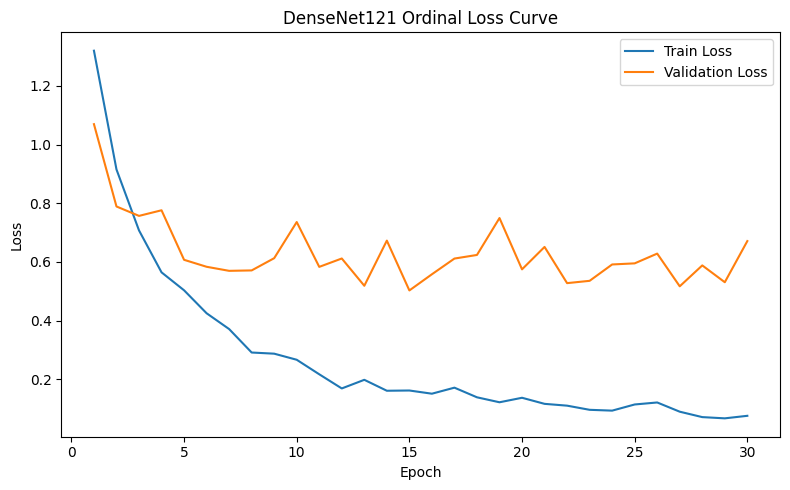

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_hybrid_chen_ordinal_loss_loss_curve.png


In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Ordinal Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_loss_curve.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


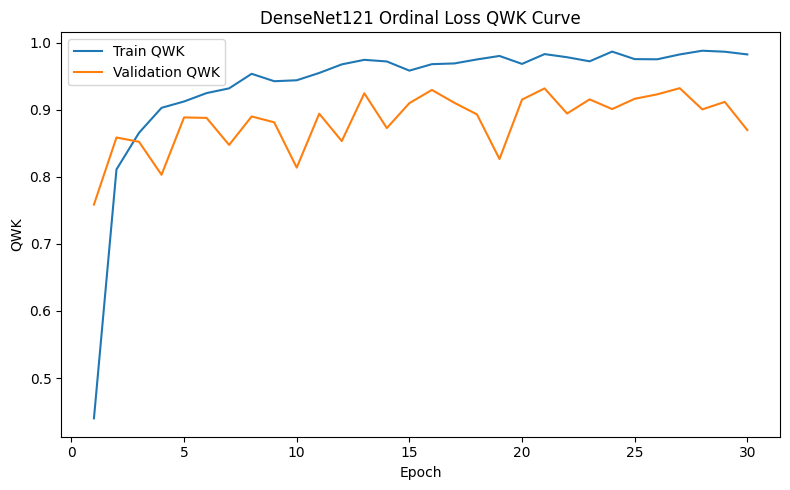

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_hybrid_chen_ordinal_loss_qwk_curve.png


In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_qwk"], label="Train QWK")
plt.plot(history_df["epoch"], history_df["val_qwk"], label="Validation QWK")

plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.title("DenseNet121 Ordinal Loss QWK Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_qwk_curve.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [17]:
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print("Test loss:", test_loss)
print_metrics(test_metrics, title="ordinal loss Test Metrics")


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test loss: 0.7367441858969578
ordinal loss Test Metrics
accuracy: 0.7993
macro_f1: 0.7872
weighted_f1: 0.7965
mae: 0.2687
qwk: 0.8835
total_errors: 59
adjacent_errors: 46
distant_errors: 13
total_error_rate: 0.2007
adjacent_error_rate: 0.1565
distant_error_rate: 0.0442


In [18]:
test_metrics_df = pd.DataFrame([{
    "experiment": EXPERIMENT_NAME,
    "loss": test_loss,
    "ordinal_alpha": ORDINAL_ALPHA,
    "penalty_distance": PENALTY_DISTANCE,
    "square_loss": SQUARE_LOSS,
    "normalize_matrix": NORMALIZE_MATRIX,
    **test_metrics
}])

test_metrics_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_test_metrics.csv"
test_metrics_path.parent.mkdir(parents=True, exist_ok=True)

test_metrics_df.to_csv(test_metrics_path, index=False)

test_metrics_df



,experiment,loss,ordinal_alpha,penalty_distance,square_loss,normalize_matrix,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,total_error_rate,adjacent_error_rate,distant_error_rate
0,densenet121_hybrid_chen_ordinal_loss,0.736744,0.1,2,False,True,0.79932,0.787152,0.796494,0.268707,0.883515,59,46,13,0.20068,0.156463,0.044218


In [19]:
from sklearn.metrics import classification_report

report_dict = classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_classification_report.csv"
report_df.to_csv(report_path)

report_df


,precision,recall,f1-score,support
0Normal,0.815534,0.923077,0.865979,91.00000
1Doubtful,0.739130,0.772727,0.755556,88.00000
2Mild,0.700000,0.552632,0.617647,38.00000
3Moderate,0.875000,0.800000,0.835821,35.00000
4Severe,0.918919,0.809524,0.860759,42.00000
accuracy,0.799320,0.799320,0.799320,0.79932
macro avg,0.809717,0.771592,0.787152,294.00000
weighted avg,0.799580,0.799320,0.796494,294.00000


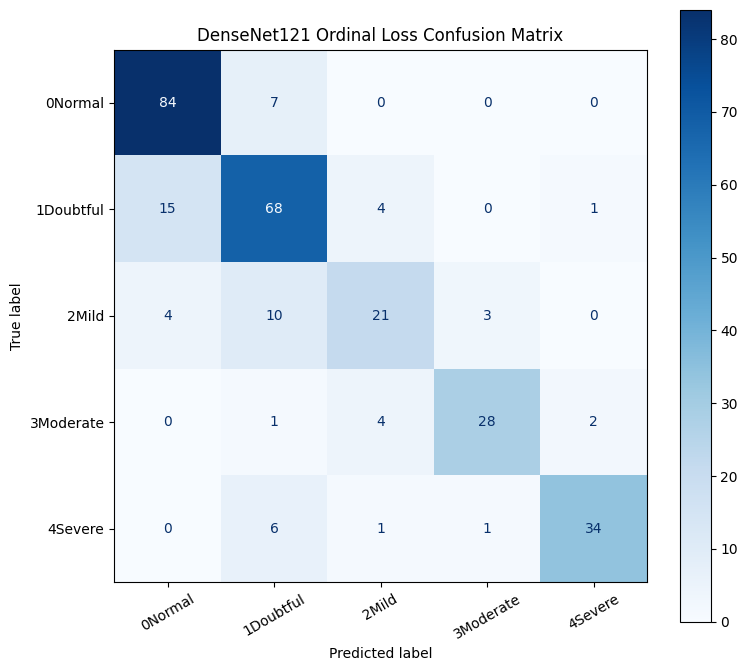

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_hybrid_chen_ordinal_loss_confusion_matrix.png


In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 Ordinal Loss Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [21]:
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names],
)

cm_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_confusion_matrix.csv"
cm_df.to_csv(cm_path)

cm_df


,Pred_0Normal,Pred_1Doubtful,Pred_2Mild,Pred_3Moderate,Pred_4Severe
True_0Normal,84,7,0,0,0
True_1Doubtful,15,68,4,0,1
True_2Mild,4,10,21,3,0
True_3Moderate,0,1,4,28,2
True_4Severe,0,6,1,1,34


In [22]:
test_true_arr = np.array(test_true)
test_pred_arr = np.array(test_pred)

error_distance = np.abs(test_true_arr - test_pred_arr)

error_summary = {
    "experiment": EXPERIMENT_NAME,
    "total_samples": len(test_true_arr),
    "correct": int(np.sum(error_distance == 0)),
    "adjacent_errors": int(np.sum(error_distance == 1)),
    "distant_errors": int(np.sum(error_distance >= 2)),
    "max_error_distance": int(np.max(error_distance)),
    "mae": float(np.mean(error_distance)),
}

error_summary_df = pd.DataFrame([error_summary])

error_summary_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_error_distance.csv"
error_summary_df.to_csv(error_summary_path, index=False)

error_summary_df




,experiment,total_samples,correct,adjacent_errors,distant_errors,max_error_distance,mae
0,densenet121_hybrid_chen_ordinal_loss,294,235,46,13,3,0.268707


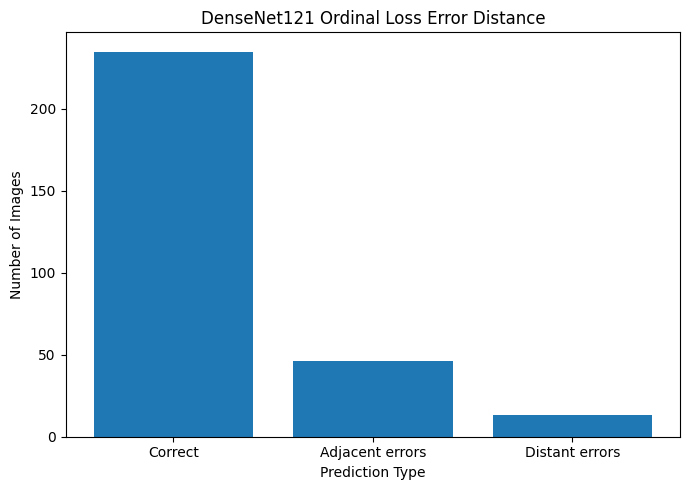

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_hybrid_chen_ordinal_loss_error_distance.png


,error_type,count
0,Correct,235
1,Adjacent errors,46
2,Distant errors,13


In [23]:
error_distance_plot_df = pd.DataFrame([
    {"error_type": "Correct", "count": error_summary["correct"]},
    {"error_type": "Adjacent errors", "count": error_summary["adjacent_errors"]},
    {"error_type": "Distant errors", "count": error_summary["distant_errors"]},
])

plt.figure(figsize=(7, 5))

plt.bar(error_distance_plot_df["error_type"], error_distance_plot_df["count"])

plt.xlabel("Prediction Type")
plt.ylabel("Number of Images")
plt.title("DenseNet121 Ordinal Loss Error Distance")
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_error_distance.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

error_distance_plot_df
